In [20]:
from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns

DATA_DIR = Path('../../data')

%config InlineBackend.figure_format = 'retina'

In [10]:
hic = pd.read_csv( DATA_DIR / 'jain_shehata/assays/hic-rt_msa.csv', index_col=0)['target'].rename('HIC RT (min)')
hic.head()

Name
ADI-38502    8.886
ADI-38501    8.959
ADI-47173    8.465
ADI-47054    8.523
ADI-47278    8.547
Name: HIC RT (min), dtype: float64

In [11]:
descriptors = pd.read_csv(DATA_DIR / 'results/06_proteinqc_jain_shehata_antibodies/descriptors.csv')
descriptors['design_id'] = descriptors.design_id.str.slice(4)  # remove the pool identifier from the design_id
descriptors = descriptors.set_index('design_id')
descriptors = descriptors.loc[hic.index]
descriptors

,Hydrophobic SAP score,Hydrophobic SASA,Hydrophobic patch area,Normalized hydrophobic patch area,Hydrophobic top1 patch area,Normalized hydrophobic top1 patch area,Hydrophobicity potential,Positive patch area at pH 5.5,Normalized positive patch area at pH 5.5,Positive top1 patch area at pH 5.5,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
Name,,,,,,,,,,,,,,,,,,,,,
ADI-38502,756.173585,101.479610,1917.809473,0.197999,829.857460,0.085676,2589.869347,454.937605,0.046969,170.451122,...,0.017266,76.719320,0.007921,26.455820,0.002731,19974.009669,7876.846512,-1626.121918,24556.903954,-4582.894285
ADI-38501,676.690120,101.999160,1665.101405,0.170814,585.902746,0.060105,2412.034431,656.479382,0.067345,275.144523,...,0.021919,191.540058,0.019649,54.878522,0.005630,15490.532492,8546.031624,-2511.194906,23113.090502,-7622.558010
ADI-47173,584.512512,108.666760,1564.884626,0.150919,891.461309,0.085974,2334.563135,1677.994992,0.161828,1431.165036,...,0.012032,101.887949,0.009826,34.684561,0.003345,15742.062196,7931.418703,-1675.183399,21598.456499,-5856.394303
ADI-47054,561.406164,104.800570,1281.552005,0.128166,319.717948,0.031974,2104.259594,344.580325,0.034461,172.848095,...,0.017286,1065.316034,0.106541,945.056447,0.094514,-7437.963994,5890.469600,-10991.443458,15014.973752,-22452.937746
ADI-47278,460.482233,102.279300,1349.970655,0.138153,839.193271,0.085881,1867.362938,924.153045,0.094576,435.318515,...,0.044550,32.329636,0.003309,28.855548,0.002953,35899.904157,18415.851581,-951.699024,39128.845519,-3228.941362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
urelumab,890.693111,106.721540,1958.664244,0.192135,614.355353,0.060265,3194.329206,254.637512,0.024979,123.683761,...,0.010444,216.765322,0.021264,42.880006,0.004206,935.574202,5360.440230,-4116.787570,14516.568331,-13580.994128
veltuzumab,590.344560,104.597990,1584.527582,0.158706,872.267882,0.087366,2168.213168,351.691031,0.035225,243.586219,...,0.024397,100.437120,0.010060,48.660875,0.004874,11387.475232,7391.161729,-3096.271772,20786.902041,-9399.426809
visilizumab,641.740048,106.954605,1748.990869,0.171557,1067.596790,0.104720,2237.237159,1326.782643,0.130143,803.801173,...,0.078274,47.778159,0.004687,18.607131,0.001825,27239.214955,16106.727724,-1373.476538,32663.581759,-5424.366803


In [12]:
def correlate_all_vs_all(descriptors, assays):
    # assert no NaNs in descriptors
    assert not descriptors.isnull().values.any()

    correlations = {}

    for assay_col in assays.columns:
        for col in descriptors.columns:
            # Calculate Spearman correlation
            corr, _ = spearmanr(descriptors[col], assays[assay_col].loc[descriptors.index], nan_policy='omit')
            correlations[(col, assay_col)] = corr

    # Create a DataFrame from the correlations
    correlation_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Spearman Correlation'])
    correlation_df = correlation_df.sort_values(by='Spearman Correlation',  ascending=False)
    correlation_df.index = pd.MultiIndex.from_tuples(correlation_df.index, names=['Descriptor', 'Assay'])
    correlation_df = correlation_df.reset_index()
    correlation_df['Abs Spearman Correlation'] = correlation_df['Spearman Correlation'].abs()
    return correlation_df

In [13]:
def show_top_correlations(correlation_df, n=2, sort_by_corr=False):
    # Show top n correlations for each assay
    correlation_df = correlation_df.sort_values(by=['Assay', 'Abs Spearman Correlation'], ascending=[True, False])
    top_correlations = correlation_df.groupby('Assay', sort=False).head(n)
    top_correlations = top_correlations.reset_index(drop=True)
    
    # display Spearman correlation with two decimals and color the cells based on correlation value
    if sort_by_corr:
        top_correlations = top_correlations.sort_values(by='Abs Spearman Correlation', ascending=False).reset_index(drop=True)
    return top_correlations.style.format({
        'Spearman Correlation': '{:.2f}',
        'Abs Spearman Correlation': '{:.2f}',
    }).background_gradient(cmap='coolwarm', vmin=0, vmax=1, subset=['Abs Spearman Correlation'])

In [17]:
corr = correlate_all_vs_all(descriptors, pd.DataFrame(hic))
corr.head()

,Descriptor,Assay,Spearman Correlation,Abs Spearman Correlation
0,Hydrophobic SAP score,HIC RT (min),0.455980,0.455980
1,Hydrophobicity potential,HIC RT (min),0.449386,0.449386
2,Hydrophobic patch area,HIC RT (min),0.375361,0.375361
3,Normalized hydrophobic patch area,HIC RT (min),0.368328,0.368328
4,Hydrophobic top1 patch area,HIC RT (min),0.352278,0.352278


In [21]:
show_top_correlations(corr)

,Descriptor,Assay,Spearman Correlation,Abs Spearman Correlation
0,Hydrophobic SAP score,HIC RT (min),0.46,0.46
1,Hydrophobicity potential,HIC RT (min),0.45,0.45


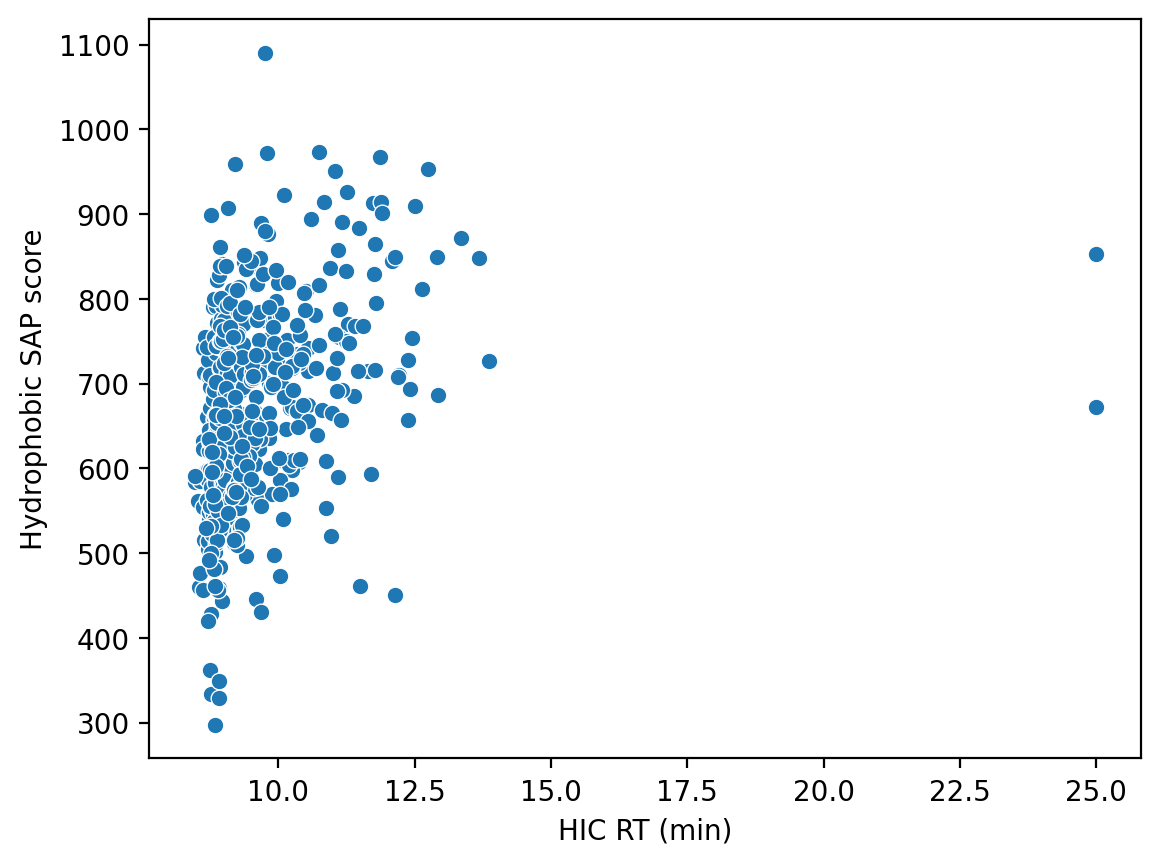

In [22]:
sns.scatterplot(y=descriptors['Hydrophobic SAP score'], x=hic);

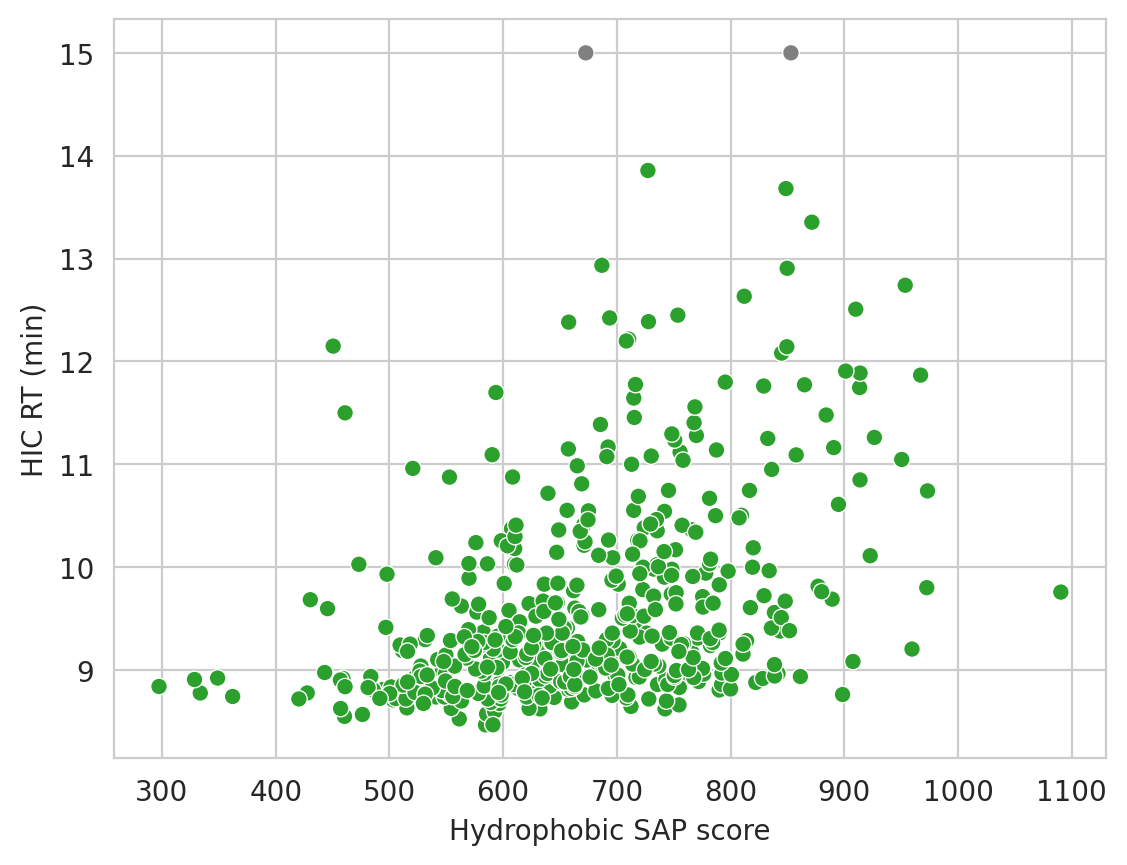

In [23]:
with sns.axes_style('whitegrid'):
    sns.scatterplot(
        x=descriptors['Hydrophobic SAP score'], 
        y=hic.replace({25.0: 15}),
        hue=hic == 25.0,
        palette={True: 'grey', False: 'tab:green'},
        legend=False
    );